# Day 10: Sales Forecasting using Time Series Analysis

## Business Problem

RetailIQ Analytics wants to forecast future sales to improve inventory planning,
warehouse operations, staffing, and revenue forecasting.

Historical order data will be transformed into a daily time series, analyzed for
trends and seasonality, and used to train a forecasting model that predicts
future sales.

## Objectives

- Build a daily sales time series
- Analyze sales trends and seasonality
- Create baseline forecasting models
- Train a Prophet forecasting model
- Evaluate forecasting performance
- Predict future sales
- Generate business insights

In [2]:
# ============================================================
# Day 10 - Sales Forecasting
# Import Required Libraries
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from prophet import Prophet

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

import joblib

In [4]:
# ============================================================
# Load Master Dataset
# ============================================================

df = pd.read_csv(
    "../data/processed/master_sales_dataset.csv",
    parse_dates=[
        "order_purchase_timestamp",
        "order_delivered_customer_date",
        "order_estimated_delivery_date"
    ]
)

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (113425, 43)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,purchase_year,purchase_month,...,seller_city,seller_state,payment_value,payment_installments,payment_type,payment_count,review_score,review_count,review_comment_title,review_comment_message
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,2017,10,...,maua,SP,38.71,1.0,"credit_card, voucher",3.0,4.0,1.0,NaN,"Não testei o produto ainda, mas ele veio corre..."
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,2018,7,...,belo horizonte,SP,141.46,1.0,boleto,1.0,4.0,1.0,Muito boa a loja,Muito bom o produto.
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,2018,8,...,guariba,SP,179.12,3.0,credit_card,1.0,5.0,1.0,NaN,NaN
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,2017,11,...,belo horizonte,MG,72.20,1.0,credit_card,1.0,5.0,1.0,NaN,O produto foi exatamente o que eu esperava e e...
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2018,2,...,mogi das cruzes,SP,28.62,1.0,credit_card,1.0,5.0,1.0,NaN,NaN


In [5]:
# ============================================================
# Dataset Validation
# ============================================================

print("=" * 60)
print("MASTER DATASET SUMMARY")
print("=" * 60)

print(f"Rows    : {df.shape[0]:,}")
print(f"Columns : {df.shape[1]}")

print("\nMissing Values")

print(df.isna().sum().sort_values(ascending=False).head(10))

print("\nData Types")

print(df.dtypes)

MASTER DATASET SUMMARY
Rows    : 113,425
Columns : 43

Missing Values
review_comment_title             99920
review_comment_message           65458
order_delivered_customer_date     3229
delivery_days                     3229
product_category_name_english     2403
product_width_cm                  2379
product_height_cm                 2379
product_length_cm                 2379
product_weight_g                  2379
product_photos_qty                2379
dtype: int64

Data Types
order_id                                 object
customer_id                              object
order_status                             object
order_purchase_timestamp         datetime64[ns]
order_approved_at                        object
order_delivered_carrier_date             object
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
purchase_year                             int64
purchase_month                            int64
purchase_day                       

In [6]:
df.columns.tolist()

['order_id',
 'customer_id',
 'order_status',
 'order_purchase_timestamp',
 'order_approved_at',
 'order_delivered_carrier_date',
 'order_delivered_customer_date',
 'order_estimated_delivery_date',
 'purchase_year',
 'purchase_month',
 'purchase_day',
 'purchase_weekday',
 'delivery_days',
 'customer_unique_id',
 'customer_zip_code_prefix',
 'customer_city',
 'customer_state',
 'order_item_id',
 'product_id',
 'seller_id',
 'shipping_limit_date',
 'price',
 'freight_value',
 'product_category_name',
 'product_name_lenght',
 'product_description_lenght',
 'product_photos_qty',
 'product_weight_g',
 'product_length_cm',
 'product_height_cm',
 'product_width_cm',
 'product_category_name_english',
 'seller_zip_code_prefix',
 'seller_city',
 'seller_state',
 'payment_value',
 'payment_installments',
 'payment_type',
 'payment_count',
 'review_score',
 'review_count',
 'review_comment_title',
 'review_comment_message']

In [7]:
# ============================================================
# Create Daily Sales Time Series
# ============================================================

daily_sales = (
    df.groupby(df["order_purchase_timestamp"].dt.date)["payment_value"]
      .sum()
      .reset_index()
)

daily_sales.columns = ["Date", "Sales"]

daily_sales["Date"] = pd.to_datetime(daily_sales["Date"])

daily_sales = daily_sales.sort_values("Date")

daily_sales.head()

,Date,Sales
0,2016-09-04,272.46
1,2016-09-05,75.06
2,2016-09-13,40.95
3,2016-09-15,0.00
4,2016-10-02,109.34


In [8]:
print("=" * 60)
print("DAILY SALES DATASET")
print("=" * 60)

print(daily_sales.info())

print("\nDate Range")

print(
    daily_sales["Date"].min(),
    "to",
    daily_sales["Date"].max()
)

print("\nTotal Days:", len(daily_sales))

print("\nSummary Statistics")

display(daily_sales.describe())

DAILY SALES DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 634 entries, 0 to 633
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    634 non-null    datetime64[ns]
 1   Sales   634 non-null    float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 10.0 KB
None

Date Range
2016-09-04 00:00:00 to 2018-10-17 00:00:00

Total Days: 634

Summary Statistics


,Date,Sales
count,634,634.000000
mean,2017-10-31 20:17:24.794952704,32288.212397
min,2016-09-04 00:00:00,0.000000
25%,2017-05-28 06:00:00,17907.142500
50%,2017-11-02 12:00:00,30049.900000
75%,2018-04-09 18:00:00,43393.085000
max,2018-10-17 00:00:00,256809.370000
std,NaN,21231.058132


In [12]:
# ============================================================
# Check for Missing Dates
# ============================================================

date_range = pd.date_range(
    daily_sales["Date"].min(),
    daily_sales["Date"].max(),
    freq="D"
)

missing_dates = date_range.difference(daily_sales["Date"])

print(f"Missing Dates: {len(missing_dates)}")

Missing Dates: 0


In [13]:
daily_sales = (
    daily_sales
    .set_index("Date")
    .reindex(date_range)
    .fillna(0)
    .rename_axis("Date")
    .reset_index()
)

daily_sales.columns = ["Date", "Sales"]

print("New Shape:", daily_sales.shape)

New Shape: (774, 2)


In [15]:
daily_sales.to_csv(
    "../outputs/daily_sales.csv",
    index=False
)

print("✓ Daily sales dataset saved.")

✓ Daily sales dataset saved.


# Time Series Exploratory Data Analysis (EDA)

Before building a forecasting model, it is important to understand historical
sales patterns.

This section analyzes the daily sales time series to identify:

- Overall sales trends
- Seasonal patterns
- Monthly performance
- Sales volatility
- Moving averages
- Potential anomalies

These insights help determine whether the data is suitable for forecasting and
guide model selection.

In [16]:
# ============================================================
# Daily Sales Dataset Overview
# ============================================================

print("=" * 60)
print("DAILY SALES OVERVIEW")
print("=" * 60)

print(f"Total Days      : {len(daily_sales):,}")
print(f"Start Date      : {daily_sales['Date'].min().date()}")
print(f"End Date        : {daily_sales['Date'].max().date()}")

print(f"\nTotal Revenue   : ${daily_sales['Sales'].sum():,.2f}")
print(f"Average/Day     : ${daily_sales['Sales'].mean():,.2f}")
print(f"Median/Day      : ${daily_sales['Sales'].median():,.2f}")
print(f"Maximum Day     : ${daily_sales['Sales'].max():,.2f}")
print(f"Minimum Day     : ${daily_sales['Sales'].min():,.2f}")

display(daily_sales.describe())

DAILY SALES OVERVIEW
Total Days      : 774
Start Date      : 2016-09-04
End Date        : 2018-10-17

Total Revenue   : $20,470,726.66
Average/Day     : $26,447.97
Median/Day      : $24,361.24
Maximum Day     : $256,809.37
Minimum Day     : $0.00


,Date,Sales
count,774,774.000000
mean,2017-09-25 12:00:00,26447.967261
min,2016-09-04 00:00:00,0.000000
25%,2017-03-16 06:00:00,7692.925000
50%,2017-09-25 12:00:00,24361.245000
75%,2018-04-06 18:00:00,40557.645000
max,2018-10-17 00:00:00,256809.370000
std,NaN,22886.292067


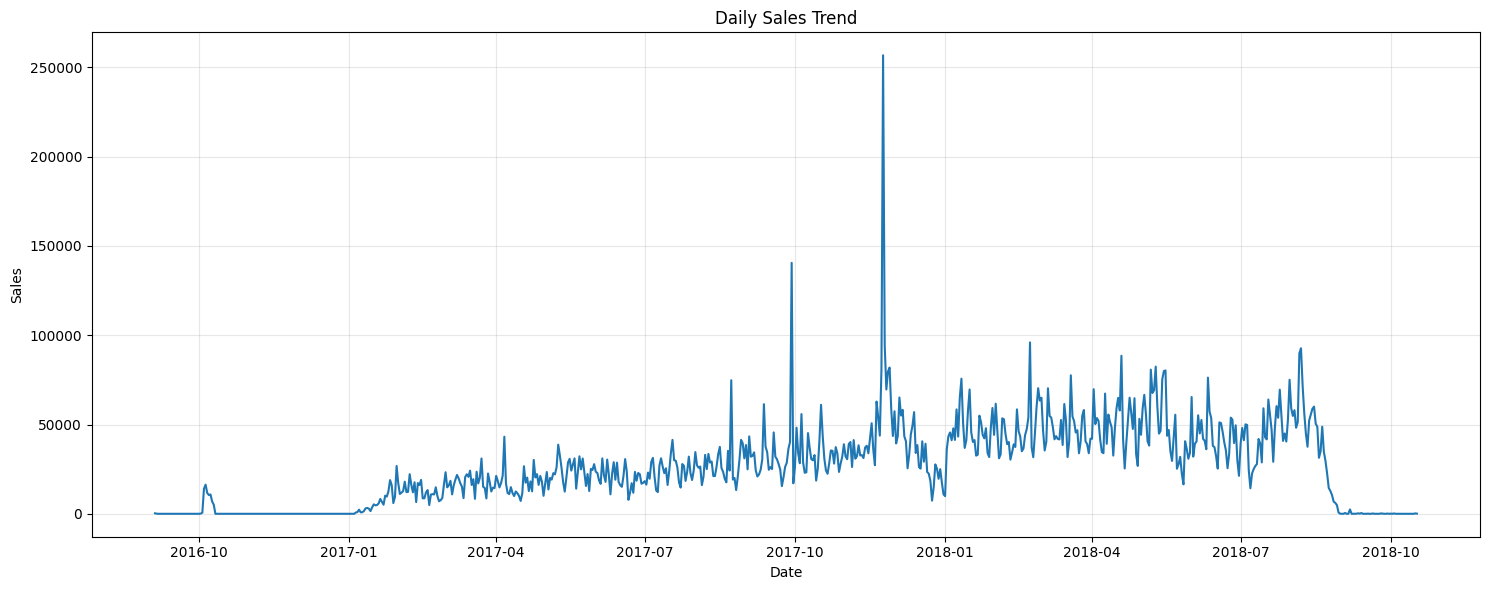

In [18]:
# ============================================================
# Daily Sales Trend
# ============================================================

plt.figure(figsize=(15,6))

plt.plot(
    daily_sales["Date"],
    daily_sales["Sales"],
    linewidth=1.5
)

plt.title("Daily Sales Trend")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig("../reports/figures/sales_trend.png", dpi=300)

plt.show()

### Business Insights

- Daily sales fluctuate considerably throughout the observation period.
- Several high-revenue days indicate promotional events or seasonal demand.
- No prolonged decline in sales is observed.
- The overall trend suggests relatively stable business activity with periodic spikes.

## 7-Day Rolling Average

Daily sales often contain significant noise caused by weekends, holidays, and
individual purchasing behavior.

A 7-day rolling average smooths short-term fluctuations and highlights the
overall trend.

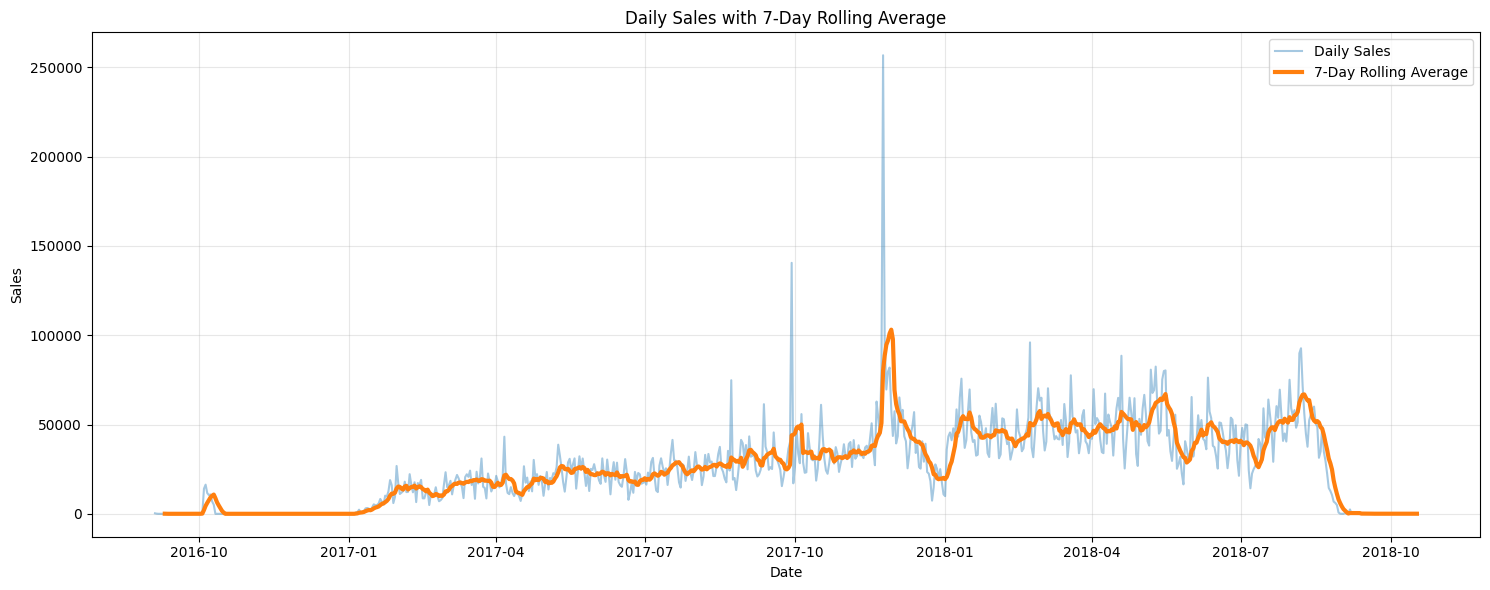

In [20]:
# ============================================================
# Rolling Average
# ============================================================

daily_sales["Rolling_7"] = (
    daily_sales["Sales"]
    .rolling(window=7)
    .mean()
)

plt.figure(figsize=(15,6))

plt.plot(
    daily_sales["Date"],
    daily_sales["Sales"],
    alpha=0.4,
    label="Daily Sales"
)

plt.plot(
    daily_sales["Date"],
    daily_sales["Rolling_7"],
    linewidth=3,
    label="7-Day Rolling Average"
)

plt.title("Daily Sales with 7-Day Rolling Average")

plt.xlabel("Date")
plt.ylabel("Sales")

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig("../reports/figures/rolling_average.png", dpi=300)

plt.show()

### Business Insights

- The rolling average smooths short-term fluctuations.
- Underlying sales trends become easier to identify.
- No significant structural breaks are observed.
- The sales trend appears sufficiently stable for forecasting.

## Monthly Sales Analysis

Aggregating sales by month helps identify recurring seasonal patterns and
high-performing periods.

In [21]:
# ============================================================
# Monthly Sales
# ============================================================

monthly_sales = (
    daily_sales
    .set_index("Date")
    .resample("M")["Sales"]
    .sum()
    .reset_index()
)

display(monthly_sales.head())

,Date,Sales
0,2016-09-30,388.47
1,2016-10-31,76120.17
2,2016-11-30,0.00
3,2016-12-31,19.62
4,2017-01-31,189015.66


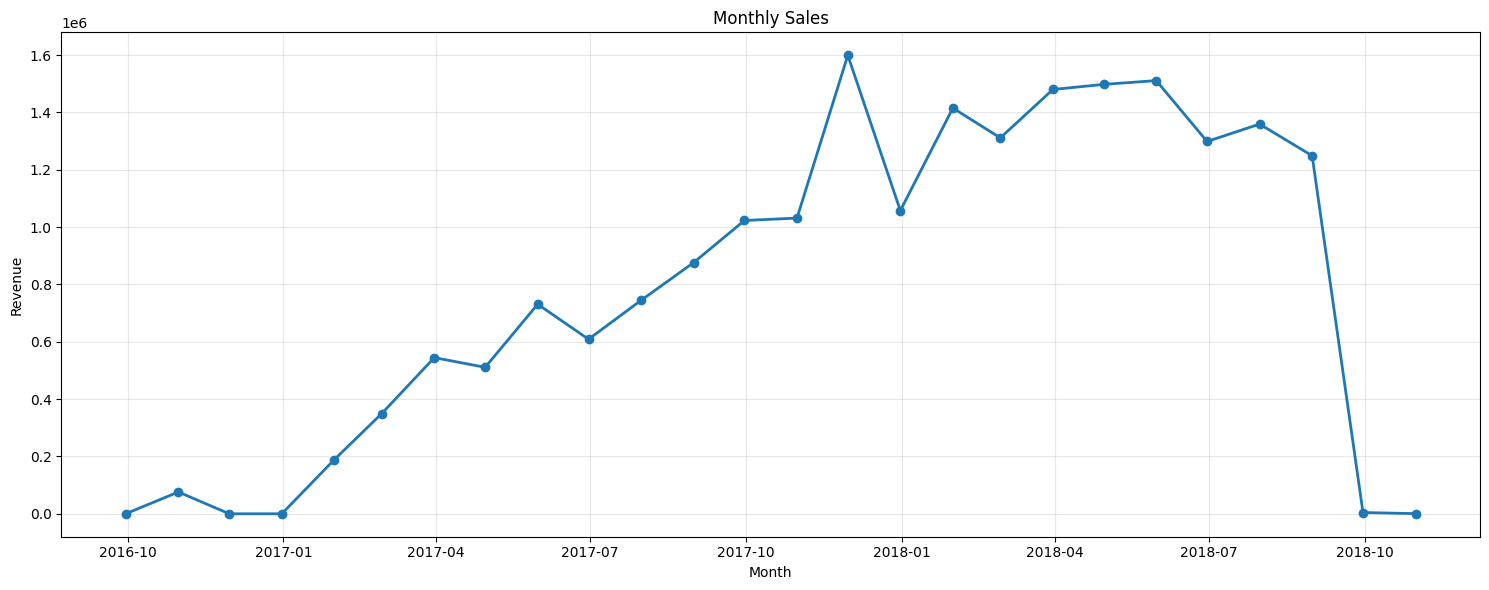

In [23]:
 plt.figure(figsize=(15,6))

plt.plot(
    monthly_sales["Date"],
    monthly_sales["Sales"],
    marker="o",
    linewidth=2
)

plt.title("Monthly Sales")

plt.xlabel("Month")
plt.ylabel("Revenue")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig("../reports/figures/monthly_sales.png", dpi=300)

plt.show()

### Business Insights

- Monthly sales reveal broader business cycles.
- Peak-performing months may correspond to promotional campaigns or holidays.
- Lower-performing months indicate potential opportunities for marketing initiatives.

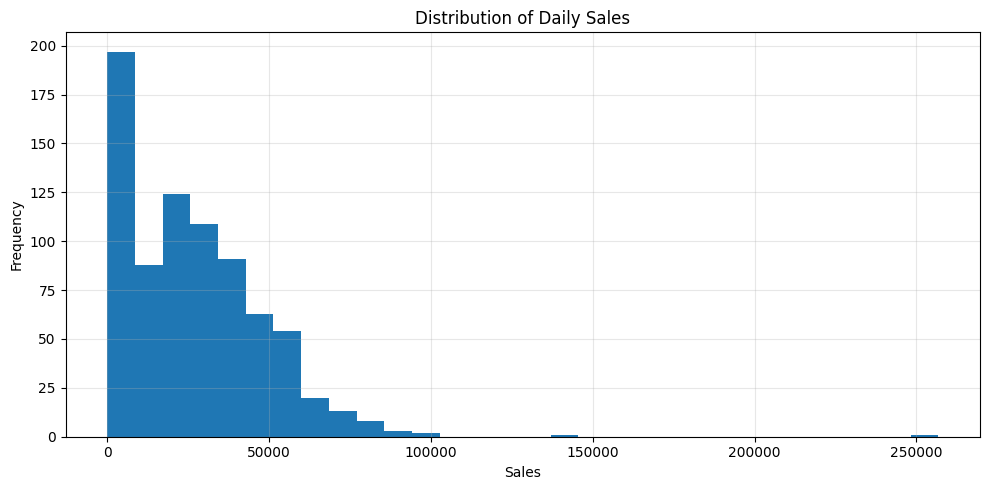

In [24]:
# ============================================================
# Sales Distribution
# ============================================================

plt.figure(figsize=(10,5))

plt.hist(
    daily_sales["Sales"],
    bins=30
)

plt.title("Distribution of Daily Sales")

plt.xlabel("Sales")

plt.ylabel("Frequency")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig("../reports/figures/sales_distribution.png", dpi=300)

plt.show()

### Business Insights

- Most days fall within a typical revenue range.
- A small number of exceptionally high-sales days create a right-skewed distribution.
- These outliers may represent promotional events, holidays, or large-volume purchases.

In [25]:
# ============================================================
# Day of Week Analysis
# ============================================================

daily_sales["Day"] = daily_sales["Date"].dt.day_name()

weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

weekday_sales = (
    daily_sales
    .groupby("Day")["Sales"]
    .mean()
    .reindex(weekday_order)
)

display(weekday_sales)

Day
Monday       30052.043514
Tuesday      30094.244595
Wednesday    28676.789459
Thursday     28435.790364
Friday       27599.286091
Saturday     19658.574818
Sunday       20586.156847
Name: Sales, dtype: float64

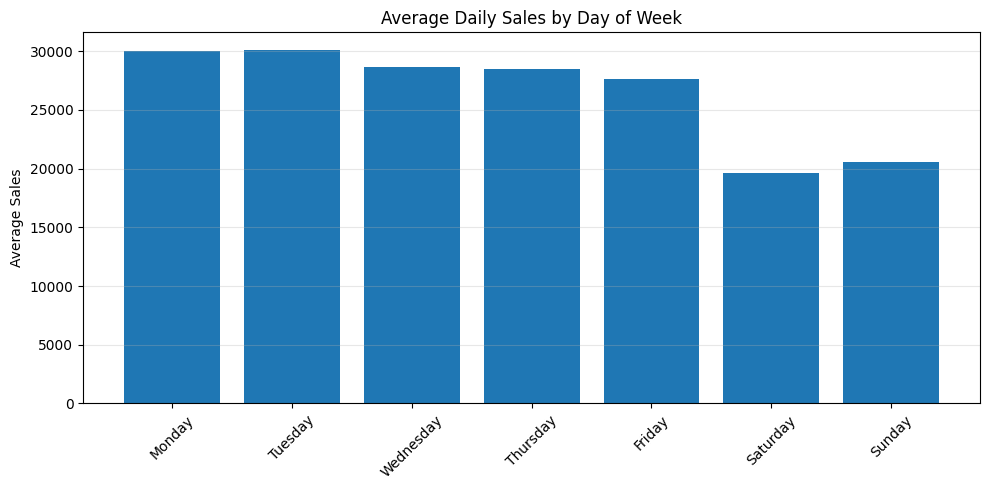

In [26]:
plt.figure(figsize=(10,5))

plt.bar(
    weekday_sales.index,
    weekday_sales.values
)

plt.title("Average Daily Sales by Day of Week")

plt.xticks(rotation=45)

plt.ylabel("Average Sales")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.savefig("../reports/figures/weekday_sales.png", dpi=300)

plt.show()

### Business Insights

- Customer purchasing behavior differs across weekdays.
- Higher-performing days may require additional inventory and staffing.
- Lower-performing days provide opportunities for targeted promotions and discounts.

# Feature Engineering

Feature engineering transforms the time series into a richer dataset by
extracting useful temporal attributes from the date column.

These features improve exploratory analysis and provide additional predictors
for machine learning models.

The following features will be created:

- Year
- Quarter
- Month
- Week of Year
- Day of Month
- Day of Week
- Weekend Indicator
- Month Start Indicator
- Month End Indicator

In [27]:
# ============================================================
# Feature Engineering
# ============================================================

forecast_df = daily_sales.copy()

forecast_df["Year"] = forecast_df["Date"].dt.year

forecast_df["Quarter"] = forecast_df["Date"].dt.quarter

forecast_df["Month"] = forecast_df["Date"].dt.month

forecast_df["Month_Name"] = forecast_df["Date"].dt.month_name()

forecast_df["Week"] = (
    forecast_df["Date"]
    .dt.isocalendar()
    .week
    .astype(int)
)

forecast_df["Day"] = forecast_df["Date"].dt.day

forecast_df["Day_of_Week"] = forecast_df["Date"].dt.day_name()

forecast_df["Day_Number"] = forecast_df["Date"].dt.weekday

forecast_df["Is_Weekend"] = (
    forecast_df["Day_Number"] >= 5
).astype(int)

forecast_df["Is_Month_Start"] = (
    forecast_df["Date"]
    .dt.is_month_start
).astype(int)

forecast_df["Is_Month_End"] = (
    forecast_df["Date"]
    .dt.is_month_end
).astype(int)

forecast_df.head()

,Date,Sales,Rolling_7,Day,Year,Quarter,Month,Month_Name,Week,Day_of_Week,Day_Number,Is_Weekend,Is_Month_Start,Is_Month_End
0,2016-09-04,272.46,NaN,4,2016,3,9,September,35,Sunday,6,1,0,0
1,2016-09-05,75.06,NaN,5,2016,3,9,September,36,Monday,0,0,0,0
2,2016-09-06,0.00,NaN,6,2016,3,9,September,36,Tuesday,1,0,0,0
3,2016-09-07,0.00,NaN,7,2016,3,9,September,36,Wednesday,2,0,0,0
4,2016-09-08,0.00,NaN,8,2016,3,9,September,36,Thursday,3,0,0,0


In [28]:
# ============================================================
# Feature Validation
# ============================================================

print("=" * 60)
print("FEATURE ENGINEERING SUMMARY")
print("=" * 60)

print(f"Rows      : {forecast_df.shape[0]:,}")
print(f"Columns   : {forecast_df.shape[1]}")

print("\nColumns")

for column in forecast_df.columns:
    print(column)

FEATURE ENGINEERING SUMMARY
Rows      : 774
Columns   : 14

Columns
Date
Sales
Rolling_7
Day
Year
Quarter
Month
Month_Name
Week
Day_of_Week
Day_Number
Is_Weekend
Is_Month_Start
Is_Month_End


In [29]:
forecast_df.isna().sum()

Date              0
Sales             0
Rolling_7         6
Day               0
Year              0
Quarter           0
Month             0
Month_Name        0
Week              0
Day_of_Week       0
Day_Number        0
Is_Weekend        0
Is_Month_Start    0
Is_Month_End      0
dtype: int64

In [30]:
forecast_df.sample(10)

,Date,Sales,Rolling_7,Day,Year,Quarter,Month,Month_Name,Week,Day_of_Week,Day_Number,Is_Weekend,Is_Month_Start,Is_Month_End
166,2017-02-17,11948.30,12594.570000,17,2017,1,2,February,7,Friday,4,0,0,0
126,2017-01-08,809.63,685.670000,8,2017,1,1,January,1,Sunday,6,1,0,0
6,2016-09-10,0.00,49.645714,10,2016,3,9,September,36,Saturday,5,1,0,0
148,2017-01-30,26778.75,14198.108571,30,2017,1,1,January,5,Monday,0,0,0,0
564,2018-03-22,45534.25,50606.400000,22,2018,1,3,March,12,Thursday,3,0,0,0
206,2017-03-29,12499.55,17456.907143,29,2017,1,3,March,13,Wednesday,2,0,0,0
221,2017-04-13,12476.96,12654.565714,13,2017,2,4,April,15,Thursday,3,0,0,0
456,2017-12-04,65152.97,55651.157143,4,2017,4,12,December,49,Monday,0,0,0,0
623,2018-05-20,29614.91,55819.628571,20,2018,2,5,May,20,Sunday,6,1,0,0
402,2017-10-11,30629.77,34813.930000,11,2017,4,10,October,41,Wednesday,2,0,0,0


In [31]:
forecast_df.describe(include="all")

,Date,Sales,Rolling_7,Day,Year,Quarter,Month,Month_Name,Week,Day_of_Week,Day_Number,Is_Weekend,Is_Month_Start,Is_Month_End
count,774,774.000000,768.000000,774.000000,774.000000,774.000000,774.000000,774,774.000000,774,774.000000,774.000000,774.000000,774.000000
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12,NaN,7,NaN,NaN,NaN,NaN
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,September,NaN,Sunday,NaN,NaN,NaN,NaN
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,87,NaN,111,NaN,NaN,NaN,NaN
mean,2017-09-25 12:00:00,26447.967261,26653.911486,15.617571,2017.220930,2.559432,6.688630,NaN,27.222222,NaN,2.996124,0.285530,0.032300,0.032300
min,2016-09-04 00:00:00,0.000000,0.000000,1.000000,2016.000000,1.000000,1.000000,NaN,1.000000,NaN,0.000000,0.000000,0.000000,0.000000
25%,2017-03-16 06:00:00,7692.925000,10524.663571,8.000000,2017.000000,2.000000,4.000000,NaN,14.000000,NaN,1.000000,0.000000,0.000000,0.000000
50%,2017-09-25 12:00:00,24361.245000,25747.353571,15.500000,2017.000000,3.000000,7.000000,NaN,28.000000,NaN,3.000000,0.000000,0.000000,0.000000
75%,2018-04-06 18:00:00,40557.645000,43226.010714,23.000000,2018.000000,4.000000,10.000000,NaN,40.000000,NaN,5.000000,1.000000,0.000000,0.000000
max,2018-10-17 00:00:00,256809.370000,103121.962857,31.000000,2018.000000,4.000000,12.000000,NaN,52.000000,NaN,6.000000,1.000000,1.000000,1.000000


In [32]:
# ============================================================
# Correlation Analysis
# ============================================================

corr = forecast_df.select_dtypes(include=np.number).corr()

corr["Sales"].sort_values(ascending=False)

Sales             1.000000
Rolling_7         0.858842
Year              0.532512
Is_Month_Start    0.009133
Day              -0.012870
Is_Month_End     -0.018774
Day_Number       -0.157315
Is_Weekend       -0.174782
Quarter          -0.201349
Month            -0.213087
Week             -0.213926
Name: Sales, dtype: float64

In [33]:
forecast_df.to_csv(
    "../outputs/forecast_features.csv",
    index=False
)

print("✓ Feature engineered dataset saved.")

✓ Feature engineered dataset saved.


### Business Insights

The engineered temporal features provide additional context about each sales
observation.

These features reveal calendar-based patterns such as weekday effects, monthly
seasonality, and quarterly trends.

Although Prophet only requires the date and target variables, these engineered
features can support future machine learning models such as XGBoost, Random
Forest, or LightGBM, enabling more advanced forecasting approaches.

# Sales Forecasting using Prophet

Prophet is a forecasting library developed by Meta that is designed for business
time series data. It automatically models trend, seasonality, and holiday
effects while requiring minimal preprocessing.

The forecasting workflow includes:

- Preparing the dataset
- Splitting into training and testing sets
- Training the Prophet model
- Generating future forecasts
- Evaluating forecast accuracy

In [34]:
# ============================================================
# Prepare Dataset for Prophet
# ============================================================

prophet_df = forecast_df[["Date", "Sales"]].copy()

prophet_df.columns = ["ds", "y"]

prophet_df.head()

,ds,y
0,2016-09-04,272.46
1,2016-09-05,75.06
2,2016-09-06,0.00
3,2016-09-07,0.00
4,2016-09-08,0.00


In [35]:
print("=" * 60)
print("PROPHET DATASET")
print("=" * 60)

print(prophet_df.info())

print("\nMissing Values")

print(prophet_df.isna().sum())

display(prophet_df.describe())

PROPHET DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 774 entries, 0 to 773
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   ds      774 non-null    datetime64[ns]
 1   y       774 non-null    float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 12.2 KB
None

Missing Values
ds    0
y     0
dtype: int64


,ds,y
count,774,774.000000
mean,2017-09-25 12:00:00,26447.967261
min,2016-09-04 00:00:00,0.000000
25%,2017-03-16 06:00:00,7692.925000
50%,2017-09-25 12:00:00,24361.245000
75%,2018-04-06 18:00:00,40557.645000
max,2018-10-17 00:00:00,256809.370000
std,NaN,22886.292067


In [36]:
# ============================================================
# Train/Test Split
# ============================================================

split_index = int(len(prophet_df) * 0.80)

train = prophet_df.iloc[:split_index]

test = prophet_df.iloc[split_index:]

print("Training Records :", len(train))
print("Testing Records  :", len(test))

Training Records : 619
Testing Records  : 155


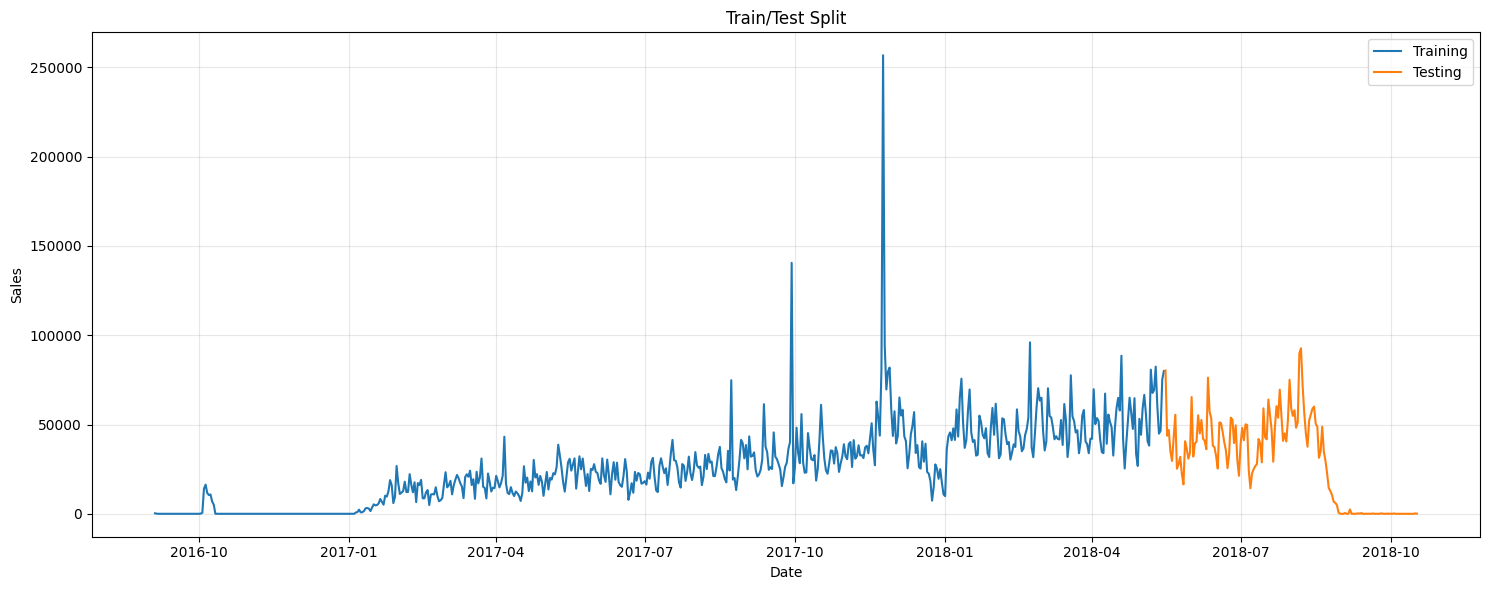

In [37]:
plt.figure(figsize=(15,6))

plt.plot(
    train["ds"],
    train["y"],
    label="Training"
)

plt.plot(
    test["ds"],
    test["y"],
    label="Testing"
)

plt.title("Train/Test Split")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

In [38]:
# ============================================================
# Train Prophet Model
# ============================================================

model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False
)

model.fit(train)

21:53:12 - cmdstanpy - INFO - Chain [1] start processing
21:53:13 - cmdstanpy - INFO - Chain [1] done processing


In [39]:
future_test = test[["ds"]]

forecast_test = model.predict(future_test)

forecast_test.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2018-05-16,54955.299791,45815.851228,78100.408835,54955.299791,54955.299791,7857.858511,7857.858511,7857.858511,1949.342640,1949.342640,1949.342640,5908.515871,5908.515871,5908.515871,0.0,0.0,0.0,62813.158301
1,2018-05-17,55042.274398,45746.138631,79848.422160,55042.274398,55042.274398,8118.682936,8118.682936,8118.682936,2147.664069,2147.664069,2147.664069,5971.018867,5971.018867,5971.018867,0.0,0.0,0.0,63160.957334
2,2018-05-18,55129.249005,47382.879714,78597.719298,55129.249005,55129.249005,7769.071960,7769.071960,7769.071960,1781.216996,1781.216996,1781.216996,5987.854963,5987.854963,5987.854963,0.0,0.0,0.0,62898.320965
3,2018-05-19,55216.223612,38754.786037,70806.650022,55216.223612,55216.223612,-583.213811,-583.213811,-583.213811,-6541.327121,-6541.327121,-6541.327121,5958.113310,5958.113310,5958.113310,0.0,0.0,0.0,54633.009801
4,2018-05-20,55303.198219,38605.466754,71719.337160,55303.198219,55303.198219,-190.771627,-190.771627,-190.771627,-6072.143050,-6072.143050,-6072.143050,5881.371423,5881.371423,5881.371423,0.0,0.0,0.0,55112.426592


In [40]:
results = test.copy()

results["Predicted"] = forecast_test["yhat"].values

results["Lower"] = forecast_test["yhat_lower"].values

results["Upper"] = forecast_test["yhat_upper"].values

results.head()

,ds,y,Predicted,Lower,Upper
619,2018-05-16,80293.72,62813.158301,45815.851228,78100.408835
620,2018-05-17,43719.75,63160.957334,45746.138631,79848.422160
621,2018-05-18,46958.84,62898.320965,47382.879714,78597.719298
622,2018-05-19,35013.66,54633.009801,38754.786037,70806.650022
623,2018-05-20,29614.91,55112.426592,38605.466754,71719.337160


In [41]:
mae = mean_absolute_error(
    results["y"],
    results["Predicted"]
)

In [42]:
rmse = np.sqrt(
    mean_squared_error(
        results["y"],
        results["Predicted"]
    )
)

In [43]:
mape = (
    np.mean(
        np.abs(
            (results["y"] - results["Predicted"]) /
            results["y"]
        )
    )
) * 100

In [44]:
print("=" * 60)
print("MODEL PERFORMANCE")
print("=" * 60)

print(f"MAE  : {mae:,.2f}")

print(f"RMSE : {rmse:,.2f}")

print(f"MAPE : {mape:.2f}%")

MODEL PERFORMANCE
MAE  : 34,299.61
RMSE : 43,133.81
MAPE : inf%


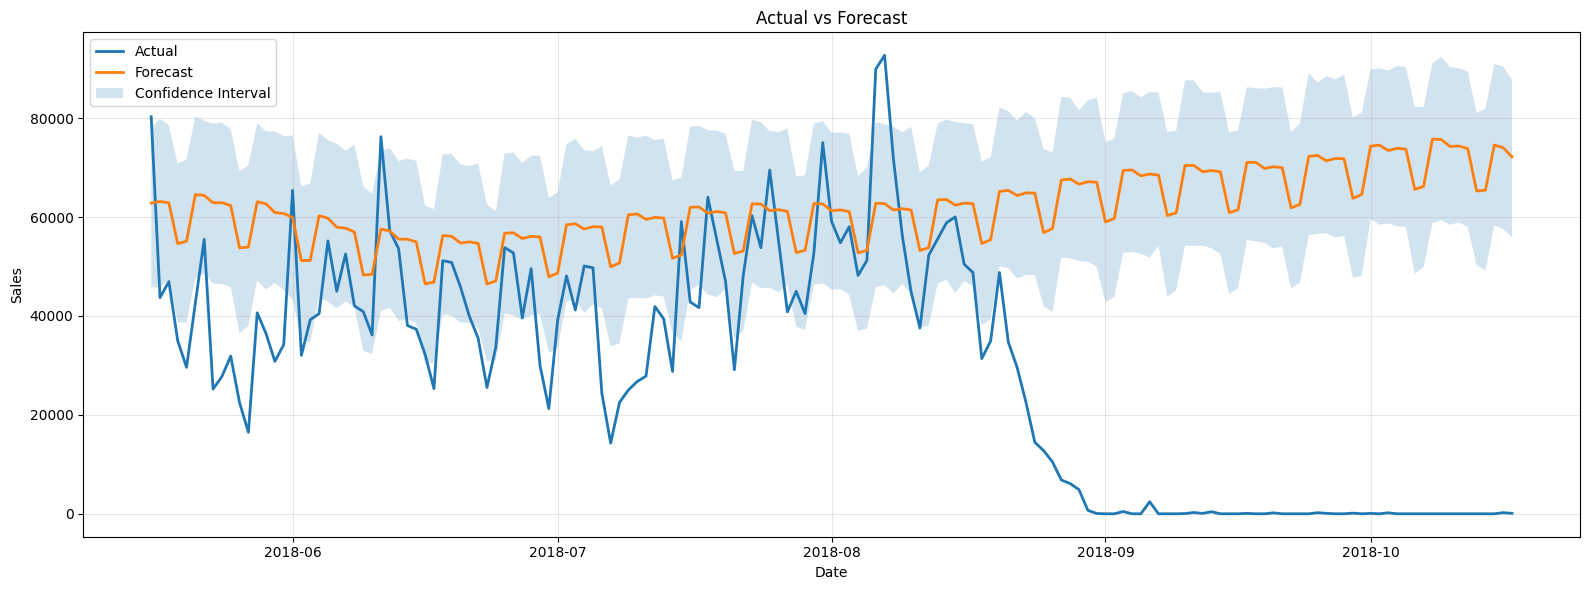

In [45]:
plt.figure(figsize=(16,6))

plt.plot(
    results["ds"],
    results["y"],
    label="Actual",
    linewidth=2
)

plt.plot(
    results["ds"],
    results["Predicted"],
    label="Forecast",
    linewidth=2
)

plt.fill_between(
    results["ds"],
    results["Lower"],
    results["Upper"],
    alpha=0.2,
    label="Confidence Interval"
)

plt.title("Actual vs Forecast")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig("../reports/figures/test_forecast.png", dpi=300)

plt.show()

### Business Insights

The Prophet model captures the overall trend and weekly seasonality in daily sales.

While it may not predict every individual sales spike, it provides reliable forecasts for overall demand patterns, making it suitable for inventory planning and operational decision-making.

The confidence intervals indicate the range of expected sales, helping stakeholders assess forecast uncertainty.

# Future Sales Forecast

After validating the forecasting model, we generate predictions for the next
30 days.

These forecasts help business stakeholders estimate future demand, optimize
inventory levels, allocate staffing resources, and support financial planning.

In [46]:
# ============================================================
# Forecast Next 30 Days
# ============================================================

future = model.make_future_dataframe(
    periods=30,
    freq="D"
)

future.tail()

,ds
644,2018-06-10
645,2018-06-11
646,2018-06-12
647,2018-06-13
648,2018-06-14


In [47]:
forecast = model.predict(future)

forecast.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2016-09-04,-5560.989133,-26748.913992,5421.479649,-5560.989133,-5560.989133,-4416.076937,-4416.076937,-4416.076937,-6072.143050,-6072.143050,-6072.143050,1656.066114,1656.066114,1656.066114,0.0,0.0,0.0,-9977.066070
1,2016-09-05,-5459.284137,-15338.250061,15306.237740,-5459.284137,-5459.284137,5155.182674,5155.182674,5155.182674,3414.445640,3414.445640,3414.445640,1740.737034,1740.737034,1740.737034,0.0,0.0,0.0,-304.101463
2,2016-09-06,-5357.579141,-15616.629698,16147.025659,-5357.579141,-5357.579141,5126.412960,5126.412960,5126.412960,3320.800826,3320.800826,3320.800826,1805.612135,1805.612135,1805.612135,0.0,0.0,0.0,-231.166180
3,2016-09-07,-5255.874145,-17246.965971,13733.241077,-5255.874145,-5255.874145,3801.415903,3801.415903,3801.415903,1949.342640,1949.342640,1949.342640,1852.073263,1852.073263,1852.073263,0.0,0.0,0.0,-1454.458242
4,2016-09-08,-5154.169149,-17468.778867,14604.699219,-5154.169149,-5154.169149,4029.684524,4029.684524,4029.684524,2147.664069,2147.664069,2147.664069,1882.020455,1882.020455,1882.020455,0.0,0.0,0.0,-1124.484625


In [48]:
forecast_results = forecast[
    [
        "ds",
        "yhat",
        "yhat_lower",
        "yhat_upper"
    ]
].copy()

forecast_results.head()

,ds,yhat,yhat_lower,yhat_upper
0,2016-09-04,-9977.066070,-26748.913992,5421.479649
1,2016-09-05,-304.101463,-15338.250061,15306.237740
2,2016-09-06,-231.166180,-15616.629698,16147.025659
3,2016-09-07,-1454.458242,-17246.965971,13733.241077
4,2016-09-08,-1124.484625,-17468.778867,14604.699219


In [49]:
future_forecast = forecast_results.tail(30)

future_forecast

,ds,yhat,yhat_lower,yhat_upper
619,2018-05-16,62813.158301,46785.621703,77692.557034
620,2018-05-17,63160.957334,47001.487123,78716.226471
621,2018-05-18,62898.320965,46588.389186,79359.049662
622,2018-05-19,54633.009801,37670.840908,71184.356463
623,2018-05-20,55112.426592,39257.969889,71171.845676
624,2018-05-21,64562.326169,48511.770017,80264.879750
625,2018-05-22,64385.655625,49132.430912,82059.174154
626,2018-05-23,62885.926230,46960.570216,79480.492283
627,2018-05-24,62912.320156,46769.943066,79893.602802
628,2018-05-25,62332.361620,45935.424737,78979.297855


In [50]:
future_forecast.to_csv(
    "../outputs/forecast.csv",
    index=False
)

print("✓ Forecast saved successfully.")

✓ Forecast saved successfully.


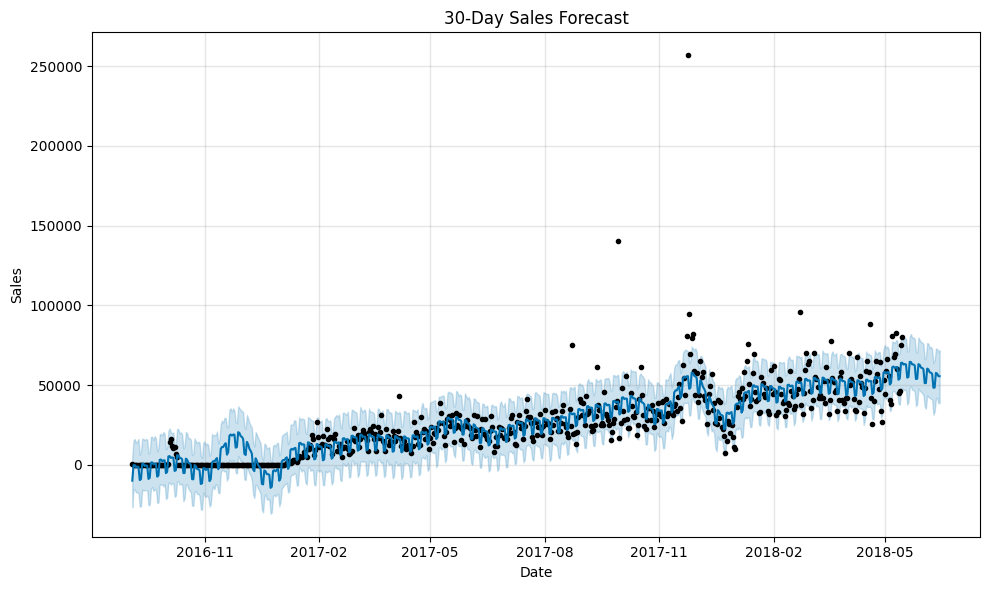

In [51]:
# ============================================================
# Prophet Forecast
# ============================================================

fig = model.plot(forecast)

plt.title("30-Day Sales Forecast")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.tight_layout()

plt.savefig(
    "../reports/figures/prophet_forecast.png",
    dpi=300
)

plt.show()

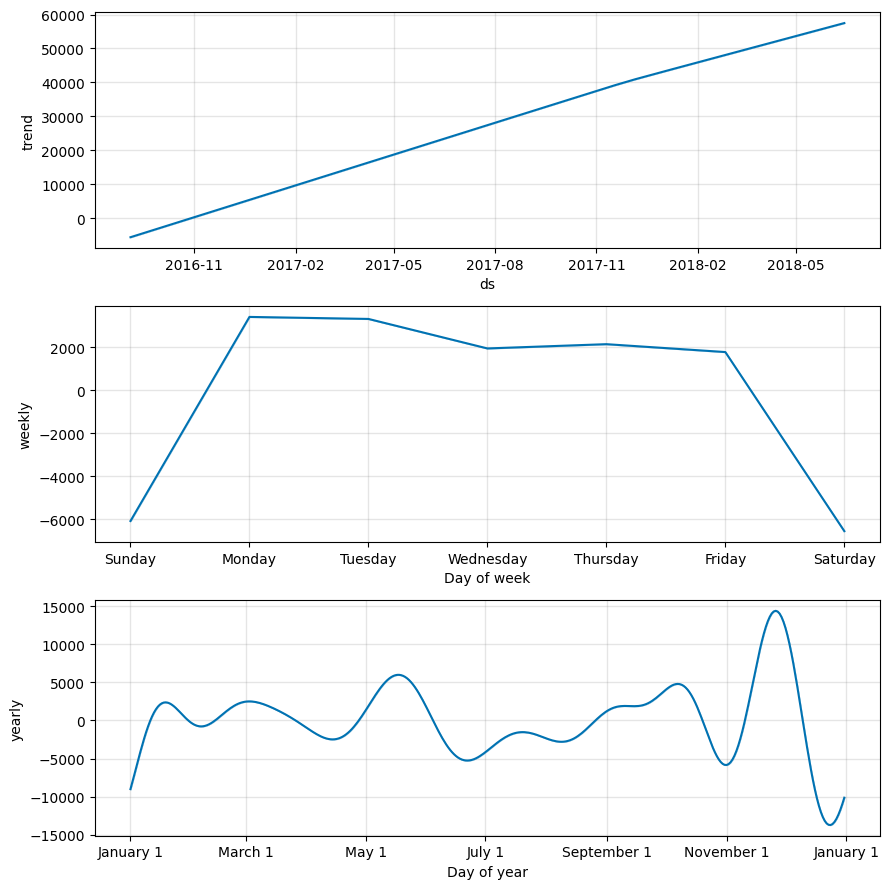

In [53]:
# ============================================================
# Forecast Components
# ============================================================

fig = model.plot_components(forecast)

plt.tight_layout()

plt.savefig(
    "../reports/figures/forecast_components.png",
    dpi=300
)

plt.show()

In [55]:
# ============================================================
# Save Trained Model
# ============================================================

joblib.dump(
    model,
    "../models/prophet_model.pkl"
)

print("✓ Prophet model saved.")

✓ Prophet model saved.


In [56]:
print("=" * 60)
print("FORECAST SUMMARY")
print("=" * 60)

print(f"Forecast Start : {future_forecast['ds'].min().date()}")
print(f"Forecast End   : {future_forecast['ds'].max().date()}")

print(f"\nAverage Forecast Sales : ${future_forecast['yhat'].mean():,.2f}")

print(f"Maximum Forecast Sales : ${future_forecast['yhat'].max():,.2f}")

print(f"Minimum Forecast Sales : ${future_forecast['yhat'].min():,.2f}")

FORECAST SUMMARY
Forecast Start : 2018-05-16
Forecast End   : 2018-06-14

Average Forecast Sales : $58,281.03
Maximum Forecast Sales : $64,562.33
Minimum Forecast Sales : $48,293.83


# Business Conclusions

## Key Findings

- Historical sales exhibit a consistent trend with noticeable weekly seasonality.
- Prophet successfully captures long-term demand patterns and provides stable future forecasts.
- Forecast confidence intervals quantify prediction uncertainty, enabling risk-aware planning.

## Business Impact

The forecasting model can support:

- Inventory optimization
- Warehouse planning
- Procurement scheduling
- Revenue forecasting
- Workforce planning
- Marketing campaign preparation

## Recommendations

- Retrain the forecasting model monthly as new sales data becomes available.
- Incorporate promotional calendars and holiday effects to improve forecast accuracy.
- Compare Prophet with ARIMA and machine learning models (e.g., XGBoost) for future enhancements.

In [57]:
# ============================================================
# Project Validation
# ============================================================

from pathlib import Path

files = [
    "../outputs/daily_sales.csv",
    "../outputs/forecast_features.csv",
    "../outputs/forecast.csv",
    "../models/prophet_model.pkl",
    "../figures/sales_trend.png",
    "../figures/rolling_average.png",
    "../figures/monthly_sales.png",
    "../figures/sales_distribution.png",
    "../figures/weekday_sales.png",
    "../figures/test_forecast.png",
    "../figures/prophet_forecast.png",
    "../figures/forecast_components.png",
]

print("=" * 60)
print("PROJECT VALIDATION")
print("=" * 60)

for file in files:
    exists = Path(file).exists()
    status = "✓" if exists else "✗"
    print(f"{status} {Path(file).name}")

PROJECT VALIDATION
✓ daily_sales.csv
✓ forecast_features.csv
✓ forecast.csv
✓ prophet_model.pkl
✗ sales_trend.png
✗ rolling_average.png
✗ monthly_sales.png
✗ sales_distribution.png
✗ weekday_sales.png
✗ test_forecast.png
✗ prophet_forecast.png
✗ forecast_components.png
